# Notebook 6: Geographical Analysis

## Objective
Visualise the geographical distribution of banking sector vulnerabilities across European countries using choropleth maps.
This analysis translates the quantitative findings from the previous notebooks into an intuitive spatial representation, highlighting regional patterns in capital adequacy across the euro area.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as mcolors

# Load clean dataset
df = pd.read_csv("banking_indicators_clean.csv")
df['Period'] = pd.to_datetime(df['Period'])
df = df[df['CET1_ratio'] < 50].copy()

# Use latest period
df_latest = df[df['Period'] == df['Period'].max()].copy()

# Country-level summary
country_stats = df_latest.groupby('Country').agg(
    avg_CET1=('CET1_ratio', 'mean'),
    min_CET1=('CET1_ratio', 'min'),
    n_banks=('Name', 'count'),
    banks_below_15=('CET1_ratio', lambda x: (x < 15).sum())
).round(2).reset_index()

print(country_stats.shape)
print(country_stats.head())

# Download world shapefile directly from Natural Earth
import urllib.request
import zipfile
import os

url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
urllib.request.urlretrieve(url, "ne_110m_admin_0_countries.zip")

with zipfile.ZipFile("ne_110m_admin_0_countries.zip", 'r') as z:
    z.extractall("ne_110m_admin_0_countries")

world = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
europe = world[world['CONTINENT'] == 'Europe'].copy()
print(europe[['NAME', 'ISO_A2']].head(10))

(25, 5)
  Country  avg_CET1  min_CET1  n_banks  banks_below_15
0      AT     17.49     12.55        5               2
1      BE     20.59     14.59        4               1
2      CY     20.63     20.63        1               0
3      DE     19.98     14.24       23               2
4      DK     17.43     16.26        3               0
        NAME ISO_A2
18    Russia     RU
21    Norway    -99
43    France    -99
110   Sweden     SE
111  Belarus     BY
112  Ukraine     UA
113   Poland     PL
114  Austria     AT
115  Hungary     HU
116  Moldova     MD


In [5]:
# Fix missing ISO_A2 codes for some countries
iso_fix = {
    'France': 'FR',
    'Norway': 'NO',
    'Finland': 'FI',
    'Kosovo': 'XK'
}
for country, code in iso_fix.items():
    europe.loc[europe['NAME'] == country, 'ISO_A2'] = code

# Merge geographical data with banking statistics
europe_merged = europe.merge(country_stats, 
                              left_on='ISO_A2', 
                              right_on='Country', 
                              how='left')

# Check merge
matched = europe_merged['avg_CET1'].notna().sum()
print(f"Countries matched: {matched} out of {len(country_stats)}")
print(europe_merged[['NAME', 'ISO_A2', 'avg_CET1']].dropna(subset=['avg_CET1']))

Countries matched: 22 out of 25
           NAME ISO_A2  avg_CET1
1        Norway     NO     18.62
2        France     FR     19.62
3        Sweden     SE     17.05
6        Poland     PL     16.47
7       Austria     AT     17.49
8       Hungary     HU     18.16
10      Romania     RO     21.30
11    Lithuania     LT     24.50
12       Latvia     LV     20.28
13      Estonia     EE     18.43
14      Germany     DE     19.98
16       Greece     GR     16.13
20   Luxembourg     LU     20.63
21      Belgium     BE     20.59
22  Netherlands     NL     24.01
23     Portugal     PT     17.42
24        Spain     ES     14.14
25      Ireland     IE     18.39
26        Italy     IT     18.61
27      Denmark     DK     17.43
30     Slovenia     SI     15.90
31      Finland     FI     17.94


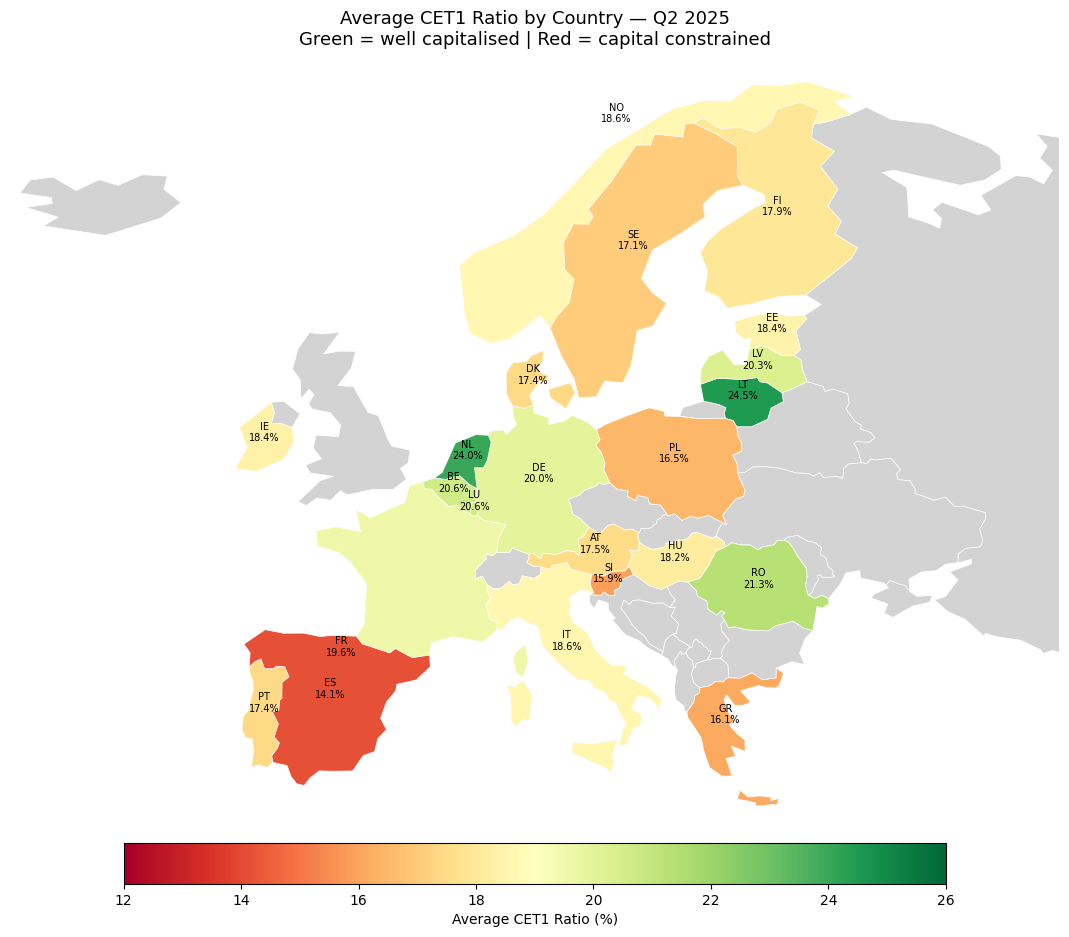

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Base map - all European countries in light grey
europe.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5)

# Choropleth - countries with banking data
europe_merged.dropna(subset=['avg_CET1']).plot(
    column='avg_CET1',
    ax=ax,
    cmap='RdYlGn',
    vmin=12,
    vmax=26,
    edgecolor='white',
    linewidth=0.5,
    legend=True,
    legend_kwds={
        'label': 'Average CET1 Ratio (%)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02
    }
)

# Focus on Europe
ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)

# Add country labels
for idx, row in europe_merged.dropna(subset=['avg_CET1']).iterrows():
    ax.annotate(
        text=f"{row['ISO_A2']}\n{row['avg_CET1']:.1f}%",
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha='center',
        fontsize=7,
        color='black'
    )

ax.set_title('Average CET1 Ratio by Country — Q2 2025\nGreen = well capitalised | Red = capital constrained',
             fontsize=13, pad=15)
ax.axis('off')

plt.tight_layout()
plt.savefig('plot_10_europe_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 1. Geographical Distribution of CET1 Ratios

The choropleth map reveals clear geographical patterns in capital adequacy across the European banking sector:

**Western periphery (capital constrained):**
Spain (ES, 14.1%) stands out as the most vulnerable country, clearly visible in red. Greece (GR, 16.1%) and Slovenia (SI, 15.9%) also show limited capital buffers.

**Core euro area (broadly solid):**
Germany (20.0%), France (19.6%), Belgium (20.6%) and Italy (18.6%) show comfortable CET1 ratios in the green-yellow range, consistent with their role as anchor economies of the euro area.

**Eastern and northern Europe (well capitalised):**
Lithuania (24.5%), Netherlands (24.0%) and Romania (21.3%) show the strongest capitalisation, reflecting conservative business models and less complex banking systems.

**Geographic pattern:**
A broad east-west gradient is visible, with eastern European banking systems generally showing higher capital ratios than western peripheral economies. This likely reflects differences in business model complexity, use of internal risk models (IRB), and legacy of post-crisis restructuring.